In [1]:
import matplotlib.pyplot as plt
import qutip
from qutip import *
import numpy as np
import scipy.integrate as integrate
from scipy.ndimage import gaussian_filter1d

### Hamiltonian

We are going to simulate an input coherent state (freely traveling wave) coming from a bath (denoted by $\alpha$) interacting with a cavity (denoted by $\hat{a}$ operators). This cavity (which only supports one mode, aka the same mode as the signal) will then interact with the atom (two level system with operators represented by $\sigma$). There is no direct interaction of the traveling wave with the atom. We add an extra term to the Hamiltonian that relates bath (signal) to cavity, to get constant offset term. So, we have two types of waves to consider: the traveling wave from the bath and the standing wave formed in the cavity. The Hamiltonian is written as                                                                                                 

$$\hat{H} = \left (\kappa\alpha_{in}(t)\hat{a}^\dagger + \kappa^* \alpha_{in}^*(t)\hat{a} \right) + \left( g(t) \hat{a}\hat{\sigma}_+ + g^*(t) \hat{a}^\dagger \hat{\sigma}_- \right )$$

- $\hat{a}$ is a bosonic quantum operator in a cavity
- $\kappa$ denotes the coupling between the bath and $\alpha_{in}$. Note this is the same $\kappa$ as in the decay terms which make sense because the decay terms come from the Hamiltonian. 
- The first term in the parentheses represents the coupling between the bath (where the signal originates from) and the cavity. The bath can arry multiple coherent states. Note: the bath term has different units from the cavity terms. 
- The second term describes the interaction between the cavity and the atom.

$\kappa$ defines the bandwidth (cavity bandiwdth defines the accpetance of the input signal), $\kappa = \sqrt{\text{FWHM of cavity}}$. This in essence is tailoring the cavity/bath coupling by defining a cavity bandwidth, which determines the acceptance of hte input signal. For example, if the input signal is too high bandwidth, it will be rejected by the cavity. Thus, we need to send in signals considered "slow" to the cavity. As an example, if $\kappa=1$, that means t he FWHM of the cavity is 1 Hz. Thus, if the Gaussian pulse occurs over a time range of less than 1 second, it might not get into the cavity. 

It would be interesting to test this: input different bandwidth signals until we see it is rejectd by the cavity.

#### Units Attention!
When I changed $\hat{a}$ from a bath operator to normal operator, the units of the a hat operator change from $\sqrt{Hz}$ to unitless as bath operators have unit of $\sqrt{Hz}$. previously, g had units of $\sqrt{Hz}$ to match Hamiltonian units (Hamiltonian has units of Hz). Now that a is unitless, g must have units of Hz. $\sigma$ operators are always unitless. 

Note that the bath has different units from the cavity operators, so you will need to transform between the two. 

To do this transform, may need to transform g by kappa, which is determined by cavity parameters like cooperativity. We do this transform to transform the coupling for the case where there is a cavity:
$g_{\text{no cav}} = g_{\text{cav}} / \kappa$

potential missing factor of 2

g depends on kappa, (gsigma terms are not bathlike so they don't show up in the lindblad terms which include the bath terms), decaying into free space


Note that we are only looking at the interaction Hamiltonian: the excess terms of $\hbar\omega_0 \hat{\sigma}_+ \hat{\sigma}_-$ and $\omega_c \hat{a}^\dagger \hat{a}$ are eliminated by transforming into the rotating frame (do this math).

### Decay Terms
Using the SLH formalism, the "quantum" terms are in the Lindblad vector (i.e. no bath terms exist, they have been factored out). The decay terms are then given by cavity relaxation (whose rate is denoted by $\kappa$). We assume no thermal photons because at least for 780 nm, it will be above the thermal backgruond.

$$ L = [\kappa \hat{a}] $$

Would have 1/cooperativity on the lindblad term in reality (high cooperativity suppresses collapse, with low cooperativity the term is not suppressed)

We do not include a spontaneous decay term $g(t)\hat{\sigma}_-$ term because because the atom will decay into the cavity rather than into an incoherent decay channel. Confused about this with the TLS. 

Confused about whether or not we can use this Fock basis. Coherent mode sent in is not a single photon.
Read SLH 7.2.2.

In [2]:
### --------- INPUT SIGNAL ---------
T = 10 # total time (input pulse "duration")
N = 5000 # number of time steps
time = np.linspace(0, T, N)

mu, sigma = 5/2, 5/10
amplitude = 0.1*np.sqrt(1/(sigma*np.sqrt(np.pi))) # small amplitude

def alpha_in(t):
    return amplitude * np.exp(-((t-mu)**2) / (2*sigma**2)) # Gaussian input
alpha = alpha_in(time)
print("Area of alpha:", integrate.simps(alpha**2, time))

Area of alpha: 0.00999999999999231


In [3]:
kappa = 100 # cavity decay rate (assuming no thermal photons)

### TEMPLATE FUNCTION (k(t) = template at time t)
def k(t):
    a = np.sqrt(1/(sigma*np.sqrt(np.pi))) # for normalized area
    return a * np.exp(-((t-mu)**2) / (2*sigma**2)) # Gaussian
    #return a * np.exp(-((t-mu)**2) / (2*sigma**2)) * np.sin(t-mu) # for orthogonal template (to input)

### COUPLING FUNCTION (g(t) = coupling strength between atom and light at time t)
def g(t):
    return 1
    integral_value, _ = integrate.quad(lambda x: np.abs(k(x))**2, 0, t) # Denominator -inf to t
    return 1/(2*kappa)*k(t) / np.sqrt(integral_value) if integral_value > 0 else 0

g_vals, k_vals = [], []
for t in time: 
    g_vals.append(g(t)) 
    k_vals.append(k(t))

print("Area of template k(t):", integrate.simps(np.array(k_vals)**2, time))

g_vals_smoothed = gaussian_filter1d(g_vals, sigma=10)  # Apply Gaussian smoothing
def g_smoothed(t):
    if t == time[0]: return 0
    else:            return np.interp(t, time, g_vals_smoothed)  # Interpolate smoothed g values

Area of template k(t): 0.9999999999992311


In [4]:
# ----------- OPERATORS ------------ 
N = 10  # dimension of Hilbert space for Fock states
a = qutip.tensor(qutip.destroy(N), qutip.qeye(2)) # Annihilation operator for cavity (acts trivally on the atom) 
sm = qutip.tensor(qutip.qeye(N), qutip.sigmam()) # Lowering operator for the atom
sp = qutip.tensor(qutip.qeye(N), qutip.sigmap()) # Raising operator for the atom

$$\hat{H} = \left ( \kappa\alpha_{in}(t)\hat{a}^\dagger + \kappa^* \alpha_{in}^*(t)\hat{a} \right) + \left( g(t) \hat{a}\hat{\sigma}_+ + g^*(t) \hat{a}^\dagger \hat{\sigma}_- \right )

= (H_1 + H_2) + (H_3 + H_4)$$

In [5]:
### ----------- HAMILTONIAN -----------
H1 = a.dag() 
H2 = a 
def H1_coeff(t, args): 
    return kappa*alpha_in(t) 
def H2_coeff(t, args): 
    return np.conjugate(kappa)*np.conjugate(alpha_in(t))

H3 = a*sp
H4 = a.dag()*sm
def H3_coeff(t, args): 
    return g_smoothed(t)
def H4_coeff(t, args): 
    return np.conjugate(g_smoothed(t))

H = [[H1, H1_coeff], [H2, H2_coeff], [H3, H3_coeff], [H4, H4_coeff]] # Final Hamiltonian

In [6]:
# DISSIPATION OPERATORES (collapse operators)
c_op_list = [kappa*a]  # time-dependent collapse term (factors of 2 see)

# --------- EXPECTATION VALUES ---------
e_ee = sp*sm # |e><e|
e_gg = sm*sp # |g><g|
S = sm # |g><e| 

e_ops=[a.dag()*a, e_ee, e_gg, S] # expectation values we want (of the bath operator to get alpha)

In [ ]:
psi0 = tensor(basis(N, 0), basis(2, 1)) # Starting atom in ground state

### SIMULATE: Solve Lindblad master equation 
result = mesolve(H, psi0, time, c_op_list, e_ops=e_ops) 
n_cavity, a_excited, a_ground, S_expect = result.expect[0], result.expect[1], result.expect[2], result.expect[3]

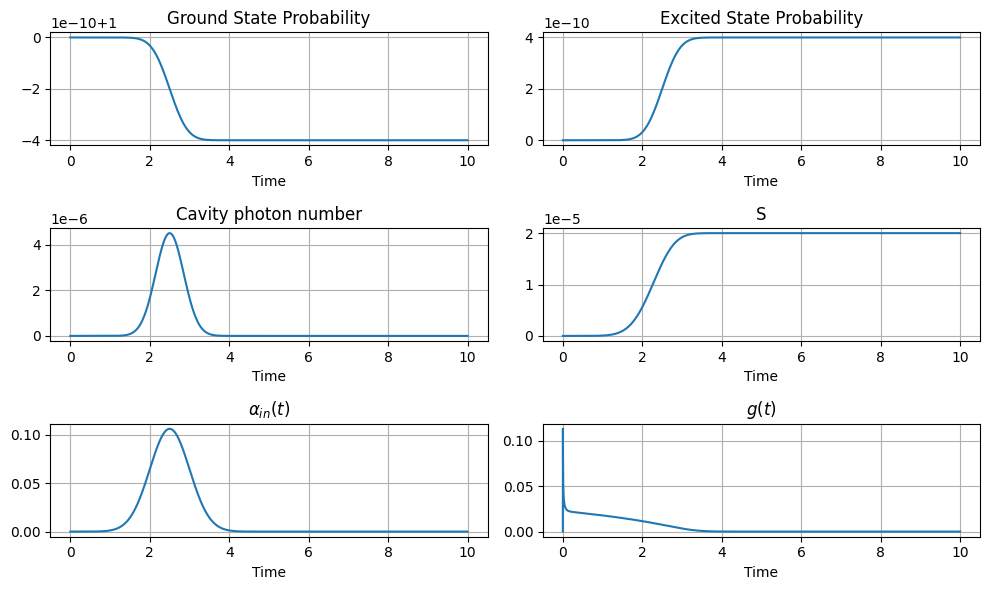

In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(10, 6))

axs[0,0].plot(time, a_ground, label="Ground State Probability")
axs[0,0].set_title("Ground State Probability")
axs[0,0].grid(True)

axs[0,1].plot(time, a_excited, label="Excited State Probability")
axs[0,1].set_title("Excited State Probability")
axs[0,1].grid(True)

axs[1,0].plot(time, n_cavity, label="Cavity photon number")
axs[1,0].set_title("Cavity photon number")
axs[1,0].grid(True)

axs[1,1].plot(time, abs(S_expect), label="<S>")
axs[1,1].set_title("S")
axs[1,1].grid(True)

axs[2,0].plot(time, alpha, label=r"$\alpha$")
axs[2,0].set_title(r"$\alpha_{in}(t)$")
axs[2,0].grid(True) 

axs[2,1].plot(time, g_vals, label=r"$g(t)$")
axs[2,1].set_title(r"$g(t)$")
axs[2,1].grid(True) 

for ax in axs.flat:
    ax.set(xlabel="Time")

fig.tight_layout()
plt.show()

What we expect to happen: Cavity photon number increases then decreases as the atom absorbs the signal. 

I should expect oscillation between the cavity and atom 

magnitude of kappa